In [ ]:
import requests

headers = {
    'Content-Type': 'application/x-www-form-urlencoded',
}

data = '{\n  "model": "gemma3",\n  "prompt": "Why is the sky blue?"\n}'

response = requests.post('http://0.0.0.0:11435/api/generate', headers=headers, data=data)

In [6]:
dir(response)

['__attrs__',
 '__bool__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__nonzero__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_content',
 '_content_consumed',
 '_next',
 'apparent_encoding',
 'close',
 'connection',
 'content',
 'cookies',
 'elapsed',
 'encoding',
 'headers',
 'history',
 'is_permanent_redirect',
 'is_redirect',
 'iter_content',
 'iter_lines',
 'json',
 'links',
 'next',
 'ok',
 'raise_for_status',
 'raw',
 'reason',
 'request',
 'status_code',
 'text',
 'url']

In [7]:
response.text

'{"model":"gemma3","created_at":"2026-03-02T08:15:12.461217Z","response":"Okay","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.470761Z","response":",","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.48053Z","response":" let","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.490376Z","response":"\'","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.500255Z","response":"s","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.51016Z","response":" break","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.520079Z","response":" down","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.530029Z","response":" why","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.540098Z","response":" the","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.550238Z","response":" sky","done":false}\n{"model":"gemma3","created_at":"2026-03-02T08:15:12.560337Z","resp

In [61]:
import os
import re
from dotenv import load_dotenv
import psycopg2

# Load environment variables from .env file
load_dotenv()

DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# Optional: fail fast if something is missing
required_vars = [DB_NAME, DB_USER, DB_HOST, DB_PORT, DB_PASSWORD]
if not all(required_vars):
    raise ValueError("One or more database environment variables are missing.")

# Connect using env variables
conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    host=DB_HOST,
    port=DB_PORT,
    password=DB_PASSWORD
)

#cur.close()
#conn.close()

In [62]:
cur = conn.cursor()
cur.execute("SELECT text_content FROM core_scrapeddata limit 100")

result = cur.fetchall()

if result:
    print(result)
else:
    print("No results found.")

cur.close()


[("Vendita Miele biologico online Azienda Agricola Vismara Gianfranco\nSkip to content\nContenuti\nmostra\n1\nAZIENDA AGRICOLA VISMARA GIANFRANCO\n1.1\nVENDITA ONLINE MIELE BIOLOGICO, OLIO DOP LAGHI LOMBARDI E DERIVATI DELL’ALVEARE; PRODUZIONE DIRETTA SENZA INTERMEDIARI.\n1.1.1\nSCOPRI I PRODOTTI DELLA NOSTRA APICOLTURA BIOLOGICA A BERGAMO, ARTIGIANALI E 100% ITALIANI!\n1.1.2\nLE NOSTRE VARIETÀ DI MIELE BIOLOGICO ITALIANO; MILLEFIORI, CASTAGNO, TIMO, ACACIA E MOLTO ALTRO ANCORA!\n1.1.3\nMIELE DA APICOLTURA BIOLOGICA NOMADE E STANZIALE\n1.1.4\nMiele da apicoltura sostenibile\n1.1.5\nSano Buono Genuino\n1.1.5.1\nSano Buono Genuino\n1.1.6\nMiele Biologico\n1.2\nMiele Biologico\n1.2.1\nOlio Extravergine d'Oliva Biologico\n1.3\nI Mieli biologici di varietà rare e pregiate:\n1.4\nI Mieli biologici di varietà rare e pregiate:\n1.4.1\nMiele Millefiori della val Brembana Bio\n1.4.2\nRicostituenti ed Energizzanti\n1.4.3\nMieli Naturali Rari e Pregiati:\n1.4.4\nCertificati da Qualitaly\n1.5\nSemp

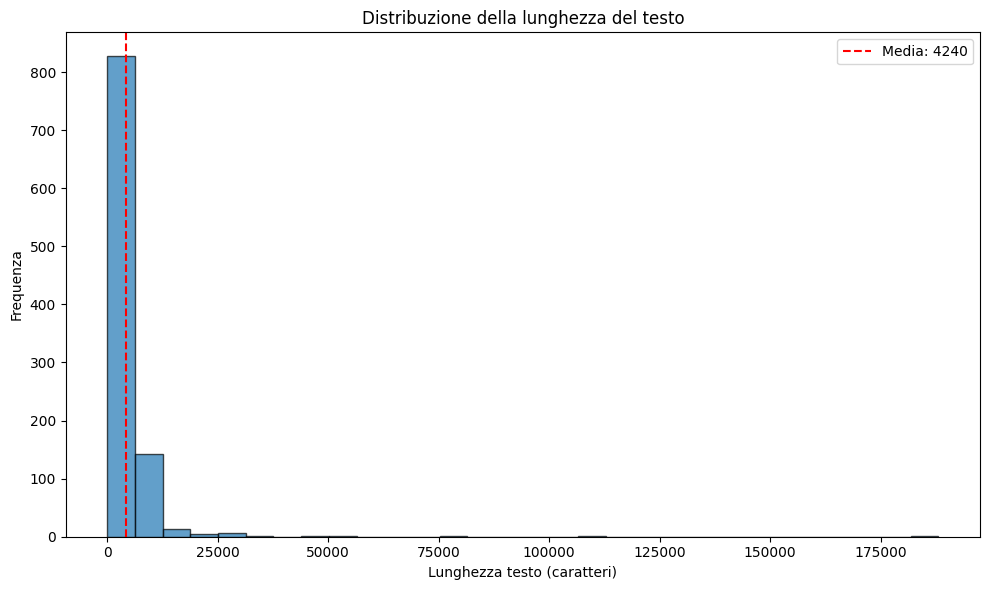

Min: 4, Max: 188079, Media: 4240, Mediana: 2877


In [65]:
import matplotlib.pyplot as plt

cur = conn.cursor()
cur.execute("SELECT text_content FROM core_scrapeddata LIMIT 1000")
result = cur.fetchall()
cur.close()

if result:
    lengths = [len(row[0]) for row in result if row[0]]

    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Lunghezza testo (caratteri)')
    plt.ylabel('Frequenza')
    plt.title('Distribuzione della lunghezza del testo')
    plt.axvline(x=sum(lengths)/len(lengths), color='red', linestyle='--', label=f'Media: {sum(lengths)/len(lengths):.0f}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Min: {min(lengths)}, Max: {max(lengths)}, Media: {sum(lengths)/len(lengths):.0f}, Mediana: {sorted(lengths)[len(lengths)//2]}")
else:
    print("No results found.")

In [37]:
result[0]

("Vendita Miele biologico online Azienda Agricola Vismara Gianfranco\nSkip to content\nContenuti\nmostra\n1\nAZIENDA AGRICOLA VISMARA GIANFRANCO\n1.1\nVENDITA ONLINE MIELE BIOLOGICO, OLIO DOP LAGHI LOMBARDI E DERIVATI DELL’ALVEARE; PRODUZIONE DIRETTA SENZA INTERMEDIARI.\n1.1.1\nSCOPRI I PRODOTTI DELLA NOSTRA APICOLTURA BIOLOGICA A BERGAMO, ARTIGIANALI E 100% ITALIANI!\n1.1.2\nLE NOSTRE VARIETÀ DI MIELE BIOLOGICO ITALIANO; MILLEFIORI, CASTAGNO, TIMO, ACACIA E MOLTO ALTRO ANCORA!\n1.1.3\nMIELE DA APICOLTURA BIOLOGICA NOMADE E STANZIALE\n1.1.4\nMiele da apicoltura sostenibile\n1.1.5\nSano Buono Genuino\n1.1.5.1\nSano Buono Genuino\n1.1.6\nMiele Biologico\n1.2\nMiele Biologico\n1.2.1\nOlio Extravergine d'Oliva Biologico\n1.3\nI Mieli biologici di varietà rare e pregiate:\n1.4\nI Mieli biologici di varietà rare e pregiate:\n1.4.1\nMiele Millefiori della val Brembana Bio\n1.4.2\nRicostituenti ed Energizzanti\n1.4.3\nMieli Naturali Rari e Pregiati:\n1.4.4\nCertificati da Qualitaly\n1.5\nSempr

In [36]:
len(result)

100

In [38]:
from typing import List, Optional
from pydantic import BaseModel, Field
from ollama import chat


class SocialLinks(BaseModel):
    linkedin: Optional[str] = None
    x: Optional[str] = None
    twitter: Optional[str] = None
    facebook: Optional[str] = None
    instagram: Optional[str] = None
    youtube: Optional[str] = None


class CompanyInfo(BaseModel):
    company_name: Optional[str] = None
    website: Optional[str] = None
    emails: List[str] = Field(default_factory=list)
    phones: List[str] = Field(default_factory=list)
    address: Optional[str] = None
    vat_or_tax_ids: List[str] = Field(default_factory=list)
    social_links: SocialLinks = Field(default_factory=SocialLinks)
    description: Optional[str] = None


def extract_company_info_ollama(
    text: str,
    model: str = "gemma3:27b",
) -> dict:
    """
    Extracts structured company info from scraped website text using Ollama Structured Outputs.
    Returns a Python dict guaranteed to match the schema (or raises validation error).
    """

    prompt = f"""
You are an information extraction system.
Extract company contact and profile details from the provided website text.

Rules:
- Return JSON ONLY (no markdown).
- If a field is missing, use null (or empty list for list fields).
- Keep description to 1-2 sentences max.
- Do not invent facts; only use what's in the text.

WEBSITE TEXT:
{text}
"""

    response = chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        format=CompanyInfo.model_json_schema(),
        options={"temperature": 0},
        stream=False,
    )

    # Validate + parse the JSON string returned by the model
    company = CompanyInfo.model_validate_json(response.message.content)
    return company.model_dump()

In [51]:
from ollama import Client
from pydantic import BaseModel

client = Client(host="http://localhost:11435")  # or 127.0.0.1


class CompanyInfo(BaseModel):
    company_name: str | None = None
    emails: list[str] = []
    phones: list[str] = []
    description: str | None = None


def extract_company_info(text: str, model: str = "gemma3:12b") -> dict:
    response = client.chat(
        model=model,
        messages=[
            {
                "role": "user",
                "content": f"""
Extract company info from the text.
Return JSON only.

TEXT:
{text}
""",
            }
        ],
        format=CompanyInfo.model_json_schema(),
        options={"temperature": 0},
    )

    company = CompanyInfo.model_validate_json(response.message.content)
    return company.model_dump()

In [52]:
extract_company_info(result[0])

{'company_name': 'AZIENDA AGRICOLA VISMARA GIANFRANCO',
 'emails': [],
 'phones': ['03909640165'],
 'description': 'Specialized in apiculture and the production of organic honey from the Bergamo hills and Val Brembana, extra virgin olive oil, and a wide range of organic products: pollen, royal jelly, propolis, honey candies, and much more.  Produces a variety of honey (monofloral and wildflower) from diverse regions of Italy.  Employs both stationary and nomadic apiculture. Certified by Qualitaly.  Offers free shipping over 75€.'}

In [54]:
extract_company_info(result[1], model='qwen3:32b')

{'company_name': 'Società Agricola Agape',
 'emails': [],
 'phones': [],
 'description': 'Agape è una giovane realtà agricola a conduzione biologica che si occupa di apicoltura nel territorio comasco. Rispetto dell’ambiente e ricerca della qualità li hanno portati a scegliere l’allevamento biologico per le loro api. Hanno scelto la pratica del nomadismo a corto raggio, che permette di gustare diverse tipologie di miele. Ogni declinazione è offerta in modo spontaneo dalla flora del loro territorio. Gli aromi unici riescono sempre a stupire, valorizzando l’aspetto locale. Producono miele di acacia e castagno sulle colline prealpine; spostano parte degli alveari sulle montagne lariane per produrre miele di tiglio e di melata. I loro valori, tra cui spiccano il rispetto dell’ambiente e la ricerca della qualità, li hanno portati a scegliere l’allevamento biologico fin dai primi alveari. Attualmente seguono 200 alveari con il metodo di allevamento biologico e sono certificati da ICEA. Per co

In [56]:
extract_company_info(result[0], model='qwen3:32b')

ValidationError: 1 validation error for CompanyInfo
  Invalid JSON: EOF while parsing a string at line 1 column 2309 [type=json_invalid, input_value='{"company_name": "Aziend...\n\\n\\n\\n\\n\\n\\n\\n', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid